# Purchased Reagents by Esteban's Lab

Generate a purchased building-block subset from Esteban's inventory by
resolving CAS numbers through PubChem and filtering the Enamine SDFs via
InChIKey matching.

**Inputs**
- `/mol_files/0. Esteban BBs/Inventario.xlsx` (extract CAS column as a list)
- `/mol_files/1. Enamine SDFs/EnamineBBStock_site_{type}_<N>.sdf`

**Outputs**
- `/mol_files/0. Esteban BBs/Purchased.smi` (cached SMILES)
- `/mol_files/0. Esteban BBs/Purchased.inchikey` (cached InChIKey list)
- `/mol_files/1. Enamine SDFs/PurchasedByEsteban_{type}_<N>.sdf`


In [8]:
# 0.3s

import py_utils as pu

FORCE_RECOMPUTE = False

INVENTORY_XLSX = "mol_files/0. Esteban BBs/Inventario.xlsx"
SMI_CACHE = "mol_files/0. Esteban BBs/Purchased.smi"
INCHIKEY_CACHE = "mol_files/0. Esteban BBs/Purchased.inchikey"

SDF_PATHS = {
    "aldehydes": "mol_files/1. Enamine SDFs/EnamineBBStock_site_Aldehydes_12040.sdf",
    "carboxylics": "mol_files/1. Enamine SDFs/EnamineBBStock_site_CarboxylicAcids_75732.sdf",
    "amines": "mol_files/1. Enamine SDFs/EnamineBBStock_site_PrimaryAmines_68264.sdf",
}

print(f"py_utils v{pu.__version__}")

py_utils v4.30


## 1. Load Inventory XLSX

Input: `/mol_files/0. Esteban BBs/Inventario.xlsx`

Output: `CAS_list`


In [9]:
# 0.2s

cas_list = pu.load_inventory_cas(INVENTORY_XLSX)
print(f"Total CAS entries: {len(cas_list)}")

[Inventory] Loaded 1163 unique CAS numbers from mol_files/0. Esteban BBs/Inventario.xlsx
Total CAS entries: 1163


## 2. Transform CAS to InChIKey

Input: `CAS_list` (Set `FORCE_RECOMPUTE = True` to refresh the cache.)

The PubChem lookup is cached in `Purchased.smi` and `Purchased.inchikey`.

Output: `SMILES_list` + `/mol_files/0. Esteban BBs/Purchased.inchikey`

In [10]:
# 17m 17.0s

smiles_list = pu.cas_to_smiles(
    cas_list,
    output_path=SMI_CACHE,
    inchikey_path=INCHIKEY_CACHE,
    use_cache=not FORCE_RECOMPUTE,
    force_refresh=FORCE_RECOMPUTE,
)
print(f"Resolved SMILES: {len(smiles_list)}")

[CAS to SMILES] Resolving 1163 CAS numbers via PubChem...
  [100/1163] Resolved: 99, Not found: 1
  [200/1163] Resolved: 195, Not found: 5
  [300/1163] Resolved: 292, Not found: 8
  [400/1163] Resolved: 391, Not found: 9
  [500/1163] Resolved: 491, Not found: 9
  [600/1163] Resolved: 588, Not found: 12
  [700/1163] Resolved: 685, Not found: 15
  [800/1163] Resolved: 785, Not found: 15
  [900/1163] Resolved: 885, Not found: 15
  [1000/1163] Resolved: 983, Not found: 17
  [1100/1163] Resolved: 1073, Not found: 27
[CAS to SMILES] Saved 1135 SMILES to mol_files/0. Esteban BBs/Purchased.smi
[CAS to InChIKey] Saved 1134 InChIKeys to mol_files/0. Esteban BBs/Purchased.inchikey
[CAS to SMILES] Completed: 1135/1163 resolved
⚠️ 28 CAS numbers not found in PubChem
Resolved SMILES: 1135


[15:44:00] WARNING: not removing hydrogen atom without neighbors
[15:44:00] Explicit valence for atom # 11 Br, 2, is greater than permitted


## 3. Get Purchased Aldehydes SDF

Input: `/mol_files/1. Enamine SDFs/EnamineBBStock_site_Aldehydes_<N>.sdf` + SMILES list

Output: `/mol_files/1. Enamine SDFs/PurchasedByEsteban_Aldehydes_<N>.sdf`


In [11]:
# 1.6s

matched_aldehydes, scanned_aldehydes, output_aldehydes = pu.filter_sdf_by_smiles(
    SDF_PATHS["aldehydes"],
    set(smiles_list),
)
print(f"Aldehydes matched: {matched_aldehydes}/{scanned_aldehydes}")
print(f"Output: {output_aldehydes}")

[15:44:00] WARNING: not removing hydrogen atom without neighbors
[15:44:00] Explicit valence for atom # 11 Br, 2, is greater than permitted


[SDF Filter] EnamineBBStock_site_Aldehydes_12040.sdf
  Scanned: 12040 molecules
  Matched: 104 molecules
  Output:  mol_files/1. Enamine SDFs/PurchasedByEsteban_Aldehydes_104.sdf
Aldehydes matched: 104/12040
Output: mol_files/1. Enamine SDFs/PurchasedByEsteban_Aldehydes_104.sdf


## 4. Get Purchased Acids SDF

Input: `/mol_files/1. Enamine SDFs/EnamineBBStock_site_CarboxylicAcids_<N>.sdf` + SMILES list

Output: `/mol_files/1. Enamine SDFs/PurchasedByEsteban_CarboxylicAcids_<N>.sdf`


In [12]:
# 13.4s

matched_acids, scanned_acids, output_acids = pu.filter_sdf_by_smiles(
    SDF_PATHS["carboxylics"],
    set(smiles_list),
)
print(f"Carboxylic acids matched: {matched_acids}/{scanned_acids}")
print(f"Output: {output_acids}")

[15:44:02] WARNING: not removing hydrogen atom without neighbors
[15:44:02] Explicit valence for atom # 11 Br, 2, is greater than permitted


[SDF Filter] EnamineBBStock_site_CarboxylicAcids_75732.sdf
  Scanned: 75732 molecules
  Matched: 45 molecules
  Output:  mol_files/1. Enamine SDFs/PurchasedByEsteban_CarboxylicAcids_45.sdf
Carboxylic acids matched: 45/75732
Output: mol_files/1. Enamine SDFs/PurchasedByEsteban_CarboxylicAcids_45.sdf


## 5. Get Purchased Amines SDF

Input: `/mol_files/1. Enamine SDFs/EnamineBBStock_site_PrimaryAmines_<N>.sdf` + SMILES list

Output: `/mol_files/1. Enamine SDFs/PurchasedByEsteban_PrimaryAmines_<N>.sdf`


In [13]:
# 9.8s

matched_amines, scanned_amines, output_amines = pu.filter_sdf_by_smiles(
    SDF_PATHS["amines"],
    set(smiles_list),
)
print(f"Primary amines matched: {matched_amines}/{scanned_amines}")
print(f"Output: {output_amines}")

[15:44:14] WARNING: not removing hydrogen atom without neighbors
[15:44:14] Explicit valence for atom # 11 Br, 2, is greater than permitted
[15:44:24] Invalid InChI prefix in generating InChI Key


[SDF Filter] EnamineBBStock_site_PrimaryAmines_68264.sdf
  Scanned: 68264 molecules
  Matched: 62 molecules
  Output:  mol_files/1. Enamine SDFs/PurchasedByEsteban_PrimaryAmines_62.sdf
Primary amines matched: 62/68264
Output: mol_files/1. Enamine SDFs/PurchasedByEsteban_PrimaryAmines_62.sdf


## 6. Summary

Print final match counts for each building-block class.



=== Purchased Building Blocks ===
Aldehydes:   104 / 12040 -> mol_files/1. Enamine SDFs/PurchasedByEsteban_Aldehydes_104.sdf
Carboxylics: 45 / 75732 -> mol_files/1. Enamine SDFs/PurchasedByEsteban_CarboxylicAcids_45.sdf
Amines:      62 / 68264 -> mol_files/1. Enamine SDFs/PurchasedByEsteban_PrimaryAmines_62.sdf


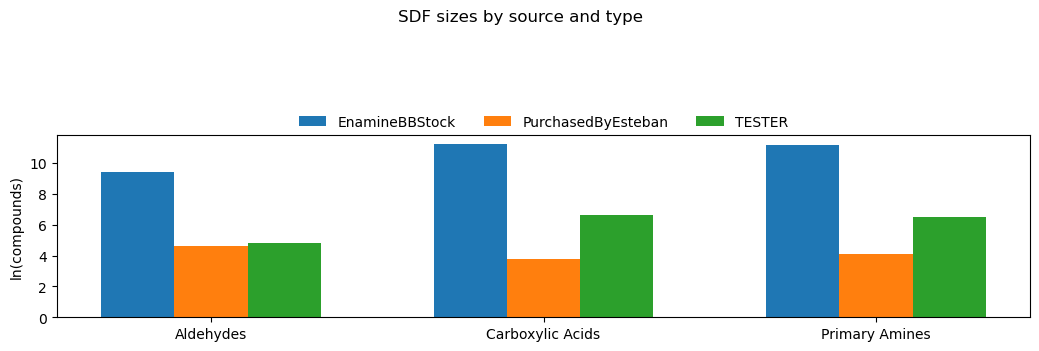

In [14]:
# 0.3s

print("\n=== Purchased Building Blocks ===")
print(f"Aldehydes:   {matched_aldehydes} / {scanned_aldehydes} -> {output_aldehydes}")
print(f"Carboxylics: {matched_acids} / {scanned_acids} -> {output_acids}")
print(f"Amines:      {matched_amines} / {scanned_amines} -> {output_amines}")

enamine_paths = {
    "Aldehydes": SDF_PATHS["aldehydes"],
    "CarboxylicAcids": SDF_PATHS["carboxylics"],
    "PrimaryAmines": SDF_PATHS["amines"],
}
purchased_paths = {
    "Aldehydes": output_aldehydes,
    "CarboxylicAcids": output_acids,
    "PrimaryAmines": output_amines,
}

pu.plot_sdf_size_summary(
    enamine_paths=enamine_paths,
    purchased_paths=purchased_paths,
)